# Fast Sampling with COMPASS

This notebook is a short, hands-on tour of the sampler improvements in `compass`.
It does **not** introduce new modelling concepts — if you haven't seen `compass`
before, start with `Gaussian_models.ipynb` or `Banana_posterior.ipynb` first.

## What changed

A recent pass over `Sampler.py` / `Trainer.py` fixed several issues that made
sampling slower and/or less accurate than it should be:

- **Vectorized score evaluation.** The score network is now called once per step
  on a batched tensor of all requested samples (and, for multi-observation
  inference, all observations at once) instead of looping in Python. Same
  math, fewer Python-level round trips.
- **Sigma-space DPM solvers (order 1/2/3).** The probability-flow ODE
  $dx = \tfrac12 g(t)^2 s(x,t)\, dt$ is exactly $dx = \sigma_m(t)\, s\, d\sigma_m(t)$
  in terms of the marginal noise scale $\sigma_m(t)$ (since $g^2 = d\sigma_m^2/dt$
  under a VESDE). The DPM predictor steps now integrate in $\sigma_m$-space
  instead of $t$-space, which removes a systematic over/under-dispersion bias
  that the old implementation had.
- **A real Euler&#8211;Maruyama `"euler"` mode.** `method="euler"` now takes proper
  reverse-SDE steps, $dx = \Delta\sigma_m^2\, s + \sqrt{\Delta\sigma_m^2}\, z$,
  instead of a drift-only update. It's the cheapest option per step (no
  corrector, no multi-stage solver) and is unbiased on average, at the cost of
  higher sample-to-sample variance for a fixed step budget.
- **Log-sigma time grids.** Diffusion steps are now spaced uniformly in
  $\log \sigma_m(t)$ rather than uniformly in $t$. Under a VESDE almost all of
  the "interesting" denoising happens at small $\sigma_m$, so a log grid spends
  far more of a fixed step budget where it matters &mdash; this matters most for
  narrow posteriors and low step counts.
- **`time_sampling="mixture"` as the new training default.** Uniform-$t$
  training data barely samples very small noise scales. `"mixture"` combines
  uniform-$t$ and log-uniform-$\sigma_m$ draws 50/50, improving analytical
  score accuracy at very small $\sigma_m$ while retaining comparable
  large-noise accuracy in the controlled linear-Gaussian diagnostic. This does
  not guarantee a narrower or better-calibrated final posterior: that still
  depends on score accuracy over the complete reverse-diffusion path.

The upshot for you as a user: sampling is faster for a given accuracy target,
and the accuracy-vs-speed dial is now `method` + `order` + `timesteps`, which
is exactly what we'll explore below.

We'll train one tiny model on CPU and then sample from it with several
solver/timestep combinations, timing each and comparing the resulting
posteriors against the analytic ground truth.

In [1]:
import time

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd

from compass import ScoreBasedInferenceModel as SBIm

torch.manual_seed(0)
np.random.seed(0)

# GPUs are busy with other jobs on this machine -- everything here runs on CPU.
device = "cpu"
print(f"Using device: {device}")

Using device: cpu


## 1. A tiny toy problem: correlated 2D Gaussian posterior

To make the sampler comparison quantitative (not just "the plots look similar"),
we use a linear-Gaussian simulator with a closed-form posterior:

$$
\theta \sim \mathcal N(0, I_2), \qquad x = A\theta + \varepsilon,\quad
\varepsilon \sim \mathcal N(0, \sigma_x^2 I_2)
$$

with a non-diagonal $A$ so that $x_1$ and $x_2$ both depend on both components
of $\theta$. This gives a correlated (but still simple/fast-to-fit) posterior,
and because everything is linear-Gaussian we can compute the exact posterior
$p(\theta \mid x_\mathrm{obs})$ in closed form to check our samples against:

$$
\Sigma_\mathrm{post} = \left(I + A^\top A / \sigma_x^2\right)^{-1}, \qquad
\mu_\mathrm{post} = \Sigma_\mathrm{post}\, A^\top x_\mathrm{obs} / \sigma_x^2
$$

In [2]:
A_MIX = torch.tensor([[1.0, 0.5],
                      [0.3, 1.0]])
NOISE_STD = 0.3


def simulate(n, noise=NOISE_STD):
    """Draw (theta, x) pairs from the linear-Gaussian toy simulator."""
    theta = torch.randn(n, 2)
    x = theta @ A_MIX.T + torch.randn(n, 2) * noise
    return theta, x


def analytic_posterior(x_obs, noise=NOISE_STD):
    """Closed-form posterior mean/covariance for a single observation x_obs."""
    noise_var = noise ** 2
    sigma_post = torch.linalg.inv(torch.eye(2) + A_MIX.T @ A_MIX / noise_var)
    mu_post = sigma_post @ A_MIX.T @ x_obs / noise_var
    return mu_post, sigma_post


# Training / validation data
theta_train, x_train = simulate(20_000)
theta_val, x_val = simulate(2_000)

print("theta_train:", theta_train.shape, " x_train:", x_train.shape)

theta_train: torch.Size([20000, 2])  x_train: torch.Size([20000, 2])


## 2. Train a small model with `time_sampling="mixture"`

The network only has to solve a 2D problem, so we can use a tiny
`ConditionTransformer` (small hidden size, 2 layers) and still get a good fit
in well under two minutes on CPU. We pass `time_sampling="mixture"` explicitly
below (it is the default, but we make it explicit since this notebook is
*about* the sampler/training changes).

In [3]:
joint_nodes = theta_train.shape[1] + x_train.shape[1]  # theta (2) + x (2)

model = SBIm(
    nodes_size=joint_nodes,
    sde_type="vesde",
    sigma=4.0,
    hidden_size=32,
    depth=2,
    num_heads=2,
    mlp_ratio=2,
    device=device,
)

t0 = time.perf_counter()
model.train(
    theta=theta_train,
    x=x_train,
    theta_val=theta_val,
    x_val=x_val,
    batch_size=256,
    max_epochs=60,
    early_stopping_patience=10,
    device=device,
    verbose=False,
    path="data/fast_sampling",
    time_sampling="mixture",
)
train_time = time.perf_counter() - t0
print(f"Training took {train_time:.1f} s")

Training took 107.6 s


## 3. Sampling with different solvers and step counts

Now we pick a single test observation and infer $p(\theta \mid x_\mathrm{obs})$
with:

- `method="dpm"`, `order=1` and `order=2` (the sigma-space DPM-Solver, with its
  default Langevin corrector steps), and
- `method="euler"` (the corrected Euler&#8211;Maruyama reverse-SDE integrator),

each at `timesteps` $\in \{10, 50, 200\}$. For every combination we time the
call with `time.perf_counter` and compare the resulting samples' mean and
covariance against the analytic posterior computed above.

In [4]:
theta_obs, x_obs = simulate(1)
mu_post, sigma_post = analytic_posterior(x_obs[0])

print("true theta:            ", theta_obs[0].numpy())
print("analytic posterior mean:", mu_post.numpy())
print("analytic posterior cov:\n", sigma_post.numpy())

true theta:             [ 1.0311168  -0.17350496]
analytic posterior mean: [ 1.2289131  -0.15394284]
analytic posterior cov:
 [[ 0.1281343  -0.07649808]
 [-0.07649808  0.11283467]]


In [5]:
configs = [
    ("dpm", 1, 10), ("dpm", 1, 50), ("dpm", 1, 200),
    ("dpm", 2, 10), ("dpm", 2, 50), ("dpm", 2, 200),
    ("euler", None, 10), ("euler", None, 50), ("euler", None, 200),
]

results = {}
rows = []
NUM_SAMPLES = 3000

for method, order, timesteps in configs:
    kwargs = dict(x=x_obs, num_samples=NUM_SAMPLES, timesteps=timesteps,
                  method=method, device=device, verbose=False)
    if method == "dpm":
        kwargs["order"] = order

    t0 = time.perf_counter()
    samples = model.sample(**kwargs)
    elapsed = time.perf_counter() - t0

    s = samples[0]  # (num_samples, 2) -- single observation
    mean_err = (s.mean(dim=0) - mu_post).norm().item()
    cov_err = (torch.cov(s.T) - sigma_post).norm().item()

    label = f"{method}" + (f" (order {order})" if order is not None else "")
    results[(label, timesteps)] = s
    rows.append({
        "solver": label,
        "timesteps": timesteps,
        "time [s]": elapsed,
        "time / sample [ms]": 1e3 * elapsed / NUM_SAMPLES,
        "|mean error|": mean_err,
        "||cov error||": cov_err,
    })

timing_df = pd.DataFrame(rows)
timing_df

,solver,timesteps,time [s],time / sample [ms],|mean error|,||cov error||
0,dpm (order 1),10,0.474023,0.158008,0.569844,0.259879
1,dpm (order 1),50,1.426122,0.475374,0.351071,0.176793
2,dpm (order 1),200,5.021567,1.673856,0.139495,0.024673
3,dpm (order 2),10,0.580540,0.193513,0.513113,0.304875
4,dpm (order 2),50,2.010768,0.670256,0.357862,0.186328
5,dpm (order 2),200,7.245538,2.415179,0.144624,0.038289
6,euler,10,0.107613,0.035871,0.485656,0.585426
7,euler,50,0.570670,0.190223,0.411338,0.294016
8,euler,200,2.326219,0.775406,0.380189,0.224449


### Visualizing the accuracy/speed trade-off

Each panel below shows samples from one solver/`timesteps` combination
(orange) against the exact posterior (blue ellipses at 1$\sigma$/2$\sigma$,
blue cross at the mean). Rows are solvers, columns are step counts; the title
of each panel reports the wall-clock sampling time for 3000 samples.

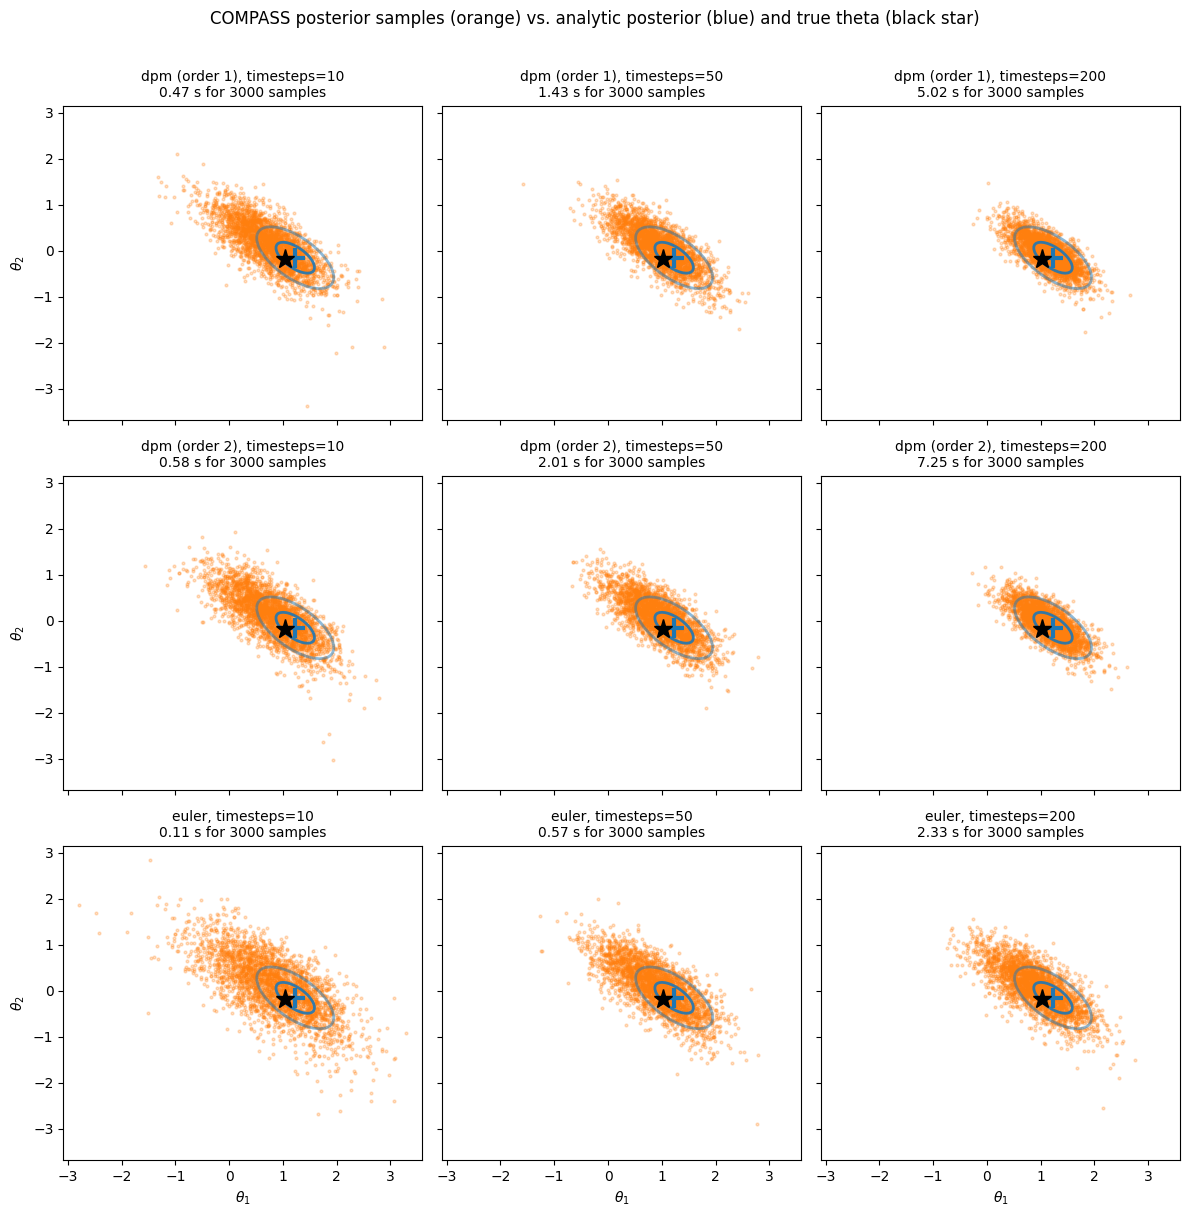

In [6]:
def draw_posterior(ax, mu, cov, **kwargs):
    vals, vecs = np.linalg.eigh(cov.numpy())
    order_ = vals.argsort()[::-1]
    vals, vecs = vals[order_], vecs[:, order_]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    for n_std, alpha in [(1, 0.9), (2, 0.5)]:
        width, height = 2 * n_std * np.sqrt(vals)
        ell = Ellipse(xy=mu.numpy(), width=width, height=height, angle=angle,
                      edgecolor="tab:blue", facecolor="none", lw=2, alpha=alpha, **kwargs)
        ax.add_patch(ell)
    ax.plot(mu[0], mu[1], "+", color="tab:blue", ms=14, mew=3, zorder=5)


solvers = ["dpm (order 1)", "dpm (order 2)", "euler"]
steps_list = [10, 50, 200]

fig, axes = plt.subplots(len(solvers), len(steps_list), figsize=(12, 12), sharex=True, sharey=True)

for i, solver in enumerate(solvers):
    for j, steps in enumerate(steps_list):
        ax = axes[i, j]
        s = results[(solver, steps)]
        row = timing_df[(timing_df["solver"] == solver) & (timing_df["timesteps"] == steps)].iloc[0]

        ax.scatter(s[:, 0], s[:, 1], s=4, alpha=0.25, color="tab:orange")
        draw_posterior(ax, mu_post, sigma_post)
        ax.plot(theta_obs[0, 0], theta_obs[0, 1], "*", color="black", ms=14, zorder=6)

        ax.set_title(f"{solver}, timesteps={steps}\n{row['time [s]']:.2f} s for {NUM_SAMPLES} samples", fontsize=10)
        if i == len(solvers) - 1:
            ax.set_xlabel(r"$\theta_1$")
        if j == 0:
            ax.set_ylabel(r"$\theta_2$")

fig.suptitle("COMPASS posterior samples (orange) vs. analytic posterior (blue) and true theta (black star)", y=1.01)
fig.tight_layout()
plt.show()

### Runtime vs. accuracy, directly

The plot below makes the trade-off explicit: `timesteps` mainly buys accuracy
at the cost of runtime, `"euler"` is the cheapest per step, and the DPM
solvers' Langevin corrector steps add a roughly constant overhead that matters
most at low `timesteps`.

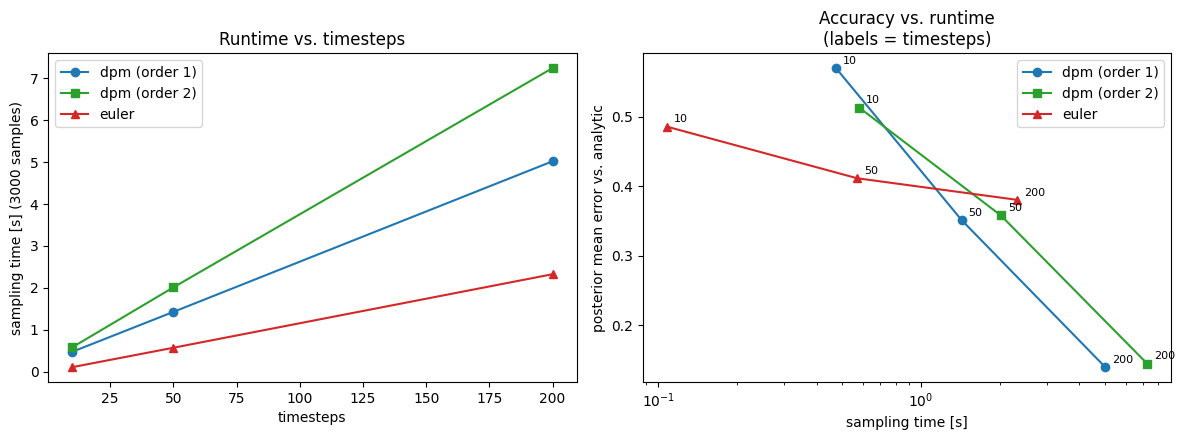

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

markers = {"dpm (order 1)": "o", "dpm (order 2)": "s", "euler": "^"}
colors = {"dpm (order 1)": "tab:blue", "dpm (order 2)": "tab:green", "euler": "tab:red"}

for solver in solvers:
    sub = timing_df[timing_df["solver"] == solver].sort_values("timesteps")
    axes[0].plot(sub["timesteps"], sub["time [s]"], marker=markers[solver], color=colors[solver], label=solver)
    axes[1].plot(sub["time [s]"], sub["|mean error|"], marker=markers[solver], color=colors[solver], label=solver)
    for _, r in sub.iterrows():
        axes[1].annotate(str(int(r["timesteps"])), (r["time [s]"], r["|mean error|"]),
                          textcoords="offset points", xytext=(5, 3), fontsize=8)

axes[0].set_xlabel("timesteps")
axes[0].set_ylabel("sampling time [s] (3000 samples)")
axes[0].set_title("Runtime vs. timesteps")
axes[0].legend()

axes[1].set_xlabel("sampling time [s]")
axes[1].set_ylabel("posterior mean error vs. analytic")
axes[1].set_title("Accuracy vs. runtime\n(labels = timesteps)")
axes[1].set_xscale("log")
axes[1].legend()

fig.tight_layout()
plt.show()

## 4. Summary: which solver/timesteps to pick

| Situation | Recommendation |
|---|---|
| Quick look / debugging a new model, many observations to sweep | `method="euler"`, `timesteps=10-50`. Cheapest per step, good enough to sanity check that the posterior is in the right place. |
| Default choice for everyday inference | `method="dpm"`, `order=2`, `timesteps=50`. Good accuracy per unit time; this is the package default. |
| Final results / narrow posteriors / publication plots | `method="dpm"`, `order=2`, `timesteps=200` (or higher). Diminishing returns set in, but this is where the log-sigma grid pays off most since it concentrates steps at the small noise scales narrow posteriors need. |
| Very large numbers of samples/observations where every step is expensive | `method="euler"` with a moderate step count, or `method="dpm"`, `order=1` &mdash; both are cheaper per step than order-2/3 DPM with correctors. |
| Compositional / multi-observation inference (`multi_obs_inference=True`) | Prefer `"dpm"` with `order=2` and enough `timesteps` (‚â•100); the vectorized score evaluation means adding more observations barely increases per-step cost, so it's the step count and solver order &mdash; not the batch of observations &mdash; that should be tuned for accuracy. |

A good rule of thumb: start cheap (`euler`, low `timesteps`) while iterating on
your simulator and network, then switch to `dpm`, `order=2`, and increase
`timesteps` for the numbers/plots that go in your final analysis.